g_xi = 0: simulating 300 trajectories at N = 100000
g_xi = 0.3: simulating 300 trajectories at N = 100000


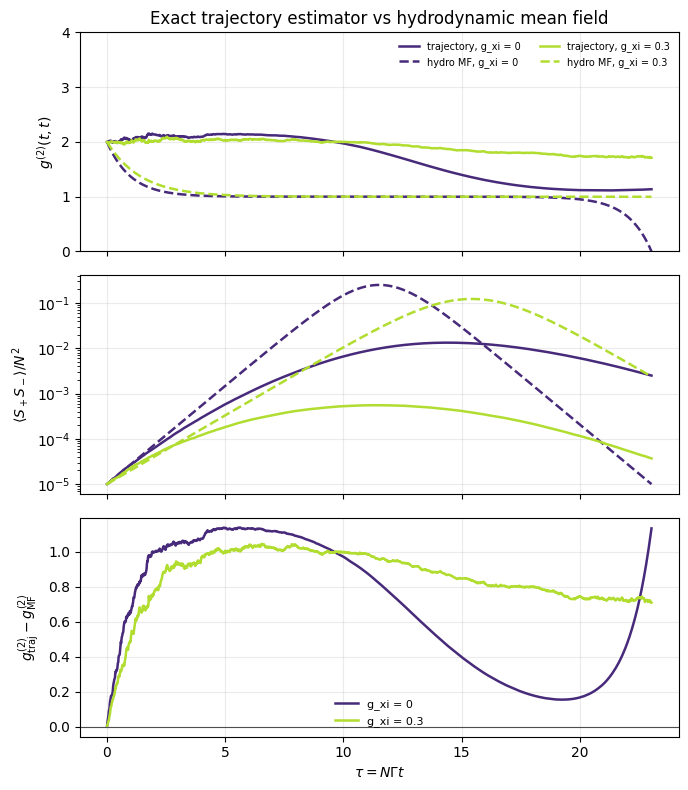

(N = 100000, Gamma = 1.0, gamma = 0.4, g_xis = [0.0, 0.3], n_traj = 300, t_fac = 2.0, nt = 1500, seed = 1234, tmax = 0.00023025850929940457, bulk_I_min = 5.0e-5, plot_I_min = 1.0e-10, outfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/plot_data/g2_mf_vs_trajectories.jld2", plotfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/data/g2_mf_vs_trajectories.pdf", curves = NamedTuple[(g_xi = 0.0, xi = 0.0, gamma = 3474.3558552260147, t = [0.0, 1.536080782517709e-7, 3.072161565035418e-7, 4.608242347553127e-7, 6.144323130070836e-7, 7.680403912588545e-7, 9.216484695106254e-7, 1.0752565477623963e-6, 1.2288646260141673e-6, 1.382472704265938e-6  …  0.00022887603659513863, 0.00022902964467339041, 0.00022918325275164217, 0.00022933686082989395, 0.0002294904689081457, 0.0002296440769863975, 0.00022979768506464925, 0.00022995129314290103, 0.0002301049012211528, 0.00023025850929940457], tau = [0.0, 0.01536080782517709, 0.03

In [9]:
#!/usr/bin/env julia

include(joinpath(@__DIR__, "MonteCarloMF.jl"))

using DifferentialEquations
using JLD2
using Printf
using Random

if !haskey(ENV, "MPLCONFIGDIR")
    mpl_config_dir = joinpath(tempdir(), "matplotlib")
    mkpath(mpl_config_dir)
    ENV["MPLCONFIGDIR"] = mpl_config_dir
end
if !haskey(ENV, "MPLBACKEND")
    ENV["MPLBACKEND"] = "Agg"
end

using PyPlot

const ROOT_DIR = normpath(joinpath(@__DIR__, ".."))

g1_sm(S, M) = Float64(S + M) * Float64(S - M + 1)

function g2_sm(S, M)
    return Float64(S + M) *
           Float64(S + M - 1) *
           Float64(S - M + 1) *
           Float64(S - M + 2)
end

function safe_divide(num, den; eps = 1e-14)
    out = similar(num, Float64)
    for i in eachindex(num, den)
        out[i] = abs(den[i]) > eps ? num[i] / den[i] : NaN
    end
    return out
end

function g2_hydro(Ifrak, m, N; eps = 1e-14)
    return abs(Ifrak) > eps ? 1.0 + 2.0 * m / (N * Ifrak) : NaN
end

function g2_deterministic_state(Ifrak, m, N; eps = 1e-14)
    # Ifrak = (s + m) * (s - m + 1/N)
    # Let b = s - m >= 0.
    # Then Ifrak = (b + 2m) * (b + 1/N).
    a = 2.0 * m + 1.0 / N
    c = 2.0 * m / N - Ifrak
    disc = max(a^2 - 4.0 * c, 0.0)

    b = 0.5 * (-a + sqrt(disc))
    s = m + b

    S = N * s
    M = N * m

    G1 = (S + M) * (S - M + 1.0)
    if abs(G1) <= eps
        return NaN
    end

    G2 = (S + M) *
         (S + M - 1.0) *
         (S - M + 1.0) *
         (S - M + 2.0)

    return G2 / G1^2
end

function trajectory_g1_g2(S, M, N, Gamma, xi)
    return (g1_sm(S, M), g2_sm(S, M))
end

function simulate_exact_g2_trajectories(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_grid,
    n_traj::Int;
    sizehint::Int = 0,
)
    sum_G1 = zeros(Float64, length(t_grid))
    sum_G2 = zeros(Float64, length(t_grid))
    sum_g2 = zeros(Float64, length(t_grid))

    for _ in 1:n_traj
        ts, obs = run_trajectory(
            N, Gamma, xi, gamma, Float64(last(t_grid)), trajectory_g1_g2;
            sizehint = sizehint,
        )

        idx = 1
        for (k, t) in enumerate(t_grid)
            while idx < length(ts) && ts[idx + 1] <= t
                idx += 1
            end
            sum_G1[k] += obs[idx][1]
            sum_G2[k] += obs[idx][2]
            sum_g2[k] += obs[idx][2] / obs[idx][1] ^ 2
        end
    end

    mean_G1 = sum_G1 ./ n_traj
    mean_G2 = sum_G2 ./ n_traj
    mean_g2 = sum_g2 ./ n_traj
    g2_exact = safe_divide(mean_G2, mean_G1 .^ 2)

    return (
        G1 = mean_G1,
        G2 = mean_G2,
        Ifrak = mean_G1 ./ N^2,
        g2 = g2_exact,
        g2_alt = mean_g2
    )
end

function solve_meanfield_g2(N, Gamma, xi, gamma, t_grid)
    p = [Gamma, xi, N, gamma]
    u0 = [1.0 / N, 0.5]
    prob = ODEProblem(meanfield_reduced!, u0, (first(t_grid), last(t_grid)), p)
    sol = solve(
        prob,
        AutoTsit5(Rosenbrock23()),
        reltol = 1e-9,
        abstol = 1e-11,
        saveat = t_grid,
    )

    Ifrak = [u[1] for u in sol.u]
    m = [u[2] for u in sol.u]
    g2_mf = [g2_hydro(I, mj, N) for (I, mj) in zip(Ifrak, m)]
    g2_mf_state = [g2_deterministic_state(I, mj, N) for (I, mj) in zip(Ifrak, m)]

    return (
        Ifrak = Ifrak,
        m = m,
        g2_hydro = g2_mf,
        g2_deterministic_state = g2_mf_state,
    )
end

function comparison_summary(curve; bulk_I_min)
    mask = [
        isfinite(curve.g2_exact[i]) &&
        isfinite(curve.g2_mf[i]) &&
        curve.I_exact[i] > bulk_I_min &&
        curve.I_mf[i] > bulk_I_min
        for i in eachindex(curve.t)
    ]

    if any(mask)
        diffs = abs.(curve.g2_exact[mask] .- curve.g2_mf[mask])
        max_abs_error = maximum(diffs)
        mean_abs_error = sum(diffs) / length(diffs)
    else
        max_abs_error = NaN
        mean_abs_error = NaN
    end

    peak_exact = argmax(curve.I_exact)
    peak_mf = argmax(curve.I_mf)

    return (
        peak_tau_exact = curve.tau[peak_exact],
        peak_tau_mf = curve.tau[peak_mf],
        g2_peak_exact = curve.g2_exact[peak_exact],
        g2_peak_mf = curve.g2_mf[peak_mf],
        max_abs_error_bulk = max_abs_error,
        mean_abs_error_bulk = mean_abs_error,
        bulk_I_min = bulk_I_min
    )
end

function plot_g2_comparison(data; outfile = data.plotfile)
    mkpath(dirname(outfile))

    fig, axes = subplots(3, 1, figsize = (7.0, 8.0), sharex = true)
    cmap = get_cmap("viridis")
    color_positions = length(data.curves) == 1 ? [0.5] : range(0.12, 0.88, length = length(data.curves))
    colors = [cmap(x) for x in color_positions]

    for (curve, color) in zip(data.curves, colors)
        label = @sprintf("g_xi = %.3g", curve.g_xi)

        exact_mask = isfinite.(curve.g2_exact) .& (curve.I_exact .> data.plot_I_min)
        mf_mask = isfinite.(curve.g2_mf) .& (curve.I_mf .> data.plot_I_min)
        err_mask = exact_mask .& mf_mask

        axes[1].plot(
            curve.tau[exact_mask],
            curve.g2_exact[exact_mask],
            color = color,
            lw = 1.8,
            label = "trajectory, " * label,
        )
        axes[1].plot(
            curve.tau[mf_mask],
            curve.g2_mf_deterministic_state[mf_mask],
            color = color,
            lw = 1.8,
            ls = "--",
            label = "hydro MF, " * label,
        )

        axes[2].plot(curve.tau, curve.I_exact, color = color, lw = 1.8)
        axes[2].plot(curve.tau, curve.I_mf, color = color, lw = 1.8, ls = "--")

        axes[3].plot(
            curve.tau[err_mask],
            curve.g2_exact[err_mask] .- curve.g2_mf[err_mask],
            color = color,
            lw = 1.8,
            label = label,
        )
    end

    axes[1].set_ylabel(L"$g^{(2)}(t,t)$")
    axes[1].set_title("Exact trajectory estimator vs hydrodynamic mean field")
    axes[1].legend(frameon = false, fontsize = 7, ncol = 2)
    axes[1].set_ylim(bottom = 0.0, top = 4.0)

    axes[2].set_ylabel(L"$\langle S_+S_-\rangle/N^2$")
    axes[2].set_yscale("log")

    axes[3].axhline(0.0, color = "0.3", lw = 0.8)
    axes[3].set_xlabel(L"$\tau=N\Gamma t$")
    axes[3].set_ylabel(L"$g^{(2)}_{\rm traj}-g^{(2)}_{\rm MF}$")
    axes[3].legend(frameon = false, fontsize = 8)

    for ax in axes
        ax.grid(true, alpha = 0.25)
    end

    fig.tight_layout()
    #fig.savefig(outfile, bbox_inches = "tight")
    return outfile
end

function compare_g2_mf_trajectories(;
    N = 10000,
    Gamma = 1.0,
    g_xis = [0.0, 0.5, 0.9],
    gamma = 0.0,
    n_traj = 300,
    t_fac = 2.0,
    nt = 1500,
    seed = 1234,
    bulk_I_min = 5.0 / N,
    plot_I_min = 1.0 / N^2,
    outfile = joinpath(ROOT_DIR, "plot_data", "g2_mf_vs_trajectories.jld2"),
    plotfile = joinpath(ROOT_DIR, "data", "g2_mf_vs_trajectories.pdf"),
)
    Random.seed!(seed)
    mkpath(dirname(outfile))
    mkpath(dirname(plotfile))

    tmax = t_fac * log(N) / (N * Gamma)
    t_grid = collect(range(0.0, tmax, length = nt))
    tau_grid = N .* Gamma .* t_grid
    curves = Vector{NamedTuple}(undef, length(g_xis))

    for (i, g_xi) in enumerate(g_xis)
        xi = Float64(g_xi) * N * Gamma
        @printf("g_xi = %.4g: simulating %d trajectories at N = %d\n", g_xi, n_traj, N)

        exact = simulate_exact_g2_trajectories(
            N, Float64(Gamma), xi, Float64(gamma) * N / log(N), t_grid, n_traj;
            sizehint = max(100, Int(ceil(2 * N))),
        )
        mf = solve_meanfield_g2(N, Float64(Gamma), xi, Float64(gamma), t_grid)

        curve_without_summary = (
            g_xi = Float64(g_xi),
            xi = xi,
            gamma = Float64(gamma) * N / log(N),
            t = t_grid,
            tau = tau_grid,
            G1_exact = exact.G1,
            G2_exact = exact.G2,
            I_exact = exact.Ifrak,
            g2_exact = exact.g2,
            I_mf = mf.Ifrak,
            m_mf = mf.m,
            g2_mf = mf.g2_hydro,
            g2_mf_deterministic_state = mf.g2_deterministic_state,
            g2_alt = exact.g2_alt
        )

        curves[i] = merge(
            curve_without_summary,
            (summary = comparison_summary(curve_without_summary; bulk_I_min = bulk_I_min),),
        )
    end

    data = (
        N = N,
        Gamma = Float64(Gamma),
        gamma = Float64(gamma),
        g_xis = collect(Float64.(g_xis)),
        n_traj = n_traj,
        t_fac = Float64(t_fac),
        nt = nt,
        seed = seed,
        tmax = tmax,
        bulk_I_min = bulk_I_min,
        plot_I_min = plot_I_min,
        outfile = outfile,
        plotfile = plotfile,
        curves = curves,
    )

    #jldsave(outfile; data...)
    plot_g2_comparison(data; outfile = plotfile)

    return data
end

compare_g2_mf_trajectories(N = 100000, gamma = 0.4, g_xis = [0.0, 0.3])



g_xi = 0: simulating 300 trajectories at N = 5000
g_xi = 0.5: simulating 300 trajectories at N = 5000
g_xi = 0.9: simulating 300 trajectories at N = 5000

Curves in the plot:
  exact MC trajectories: direct trajectory estimator <G2>/<G1>^2
  deterministic MF path (exact state): mean-field trajectory evaluated with finite-N Dicke-state G1 and G2
  MF + first-event waiting time: deterministic MF path averaged over the first spontaneous-emission time, including the no-event survival term

Summary, comparing only points with both normalized intensities above bulk_I_min:
g_xi = 0: r 0, tau_peak traj 8.864, deterministic 8.506, first-event 8.506, g2_peak traj 1.09341, deterministic 1, first-event 1, mean |err| deterministic 1.258, first-event 1.258
g_xi = 0.5: r 0, tau_peak traj 13.26, deterministic 14.25, first-event 14.25, g2_peak traj 1.11666, deterministic 1.00159, first-event 1.00159, mean |err| deterministic 1.038, first-event 1.038
g_xi = 0.9: r 0, tau_peak traj 16.84, deterministic 2

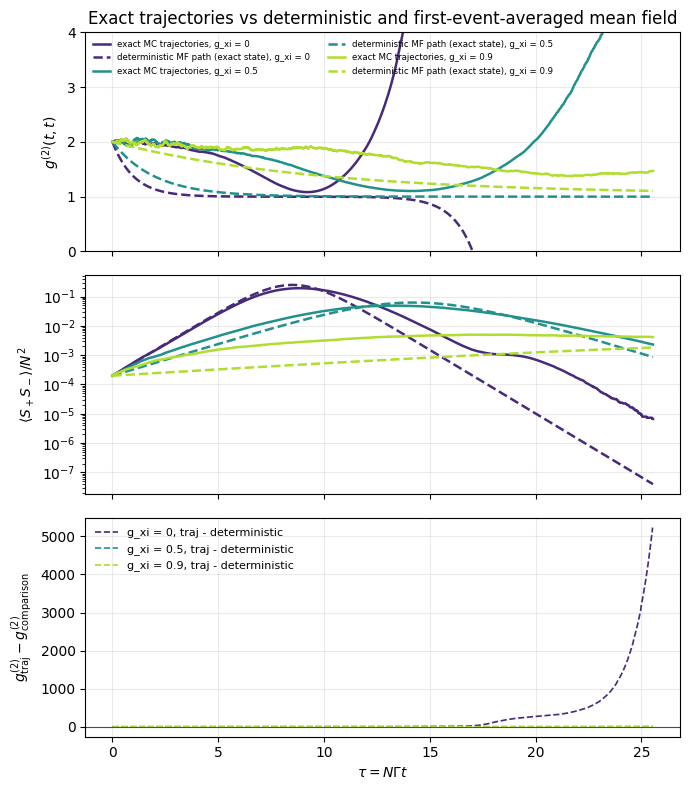

(N = 5000, Gamma = 1.0, gamma = 0.0, g_xis = [0.0, 0.5, 0.9], n_traj = 300, t_fac = 3.0, nt = 1500, seed = 1234, tmax = 0.005110315914849743, bulk_I_min = 0.001, plot_I_min = 4.0e-8, first_event_rate = nothing, n_event = 1001, outfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/plot_data/g2_mf_vs_trajectories.jld2", plotfile = "/Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/data/g2_mf_vs_trajectories.pdf", curves = NamedTuple[(g_xi = 0.0, xi = 0.0, gamma = 0.0, first_event_rate = 0.0, t = [0.0, 3.409150043262003e-6, 6.818300086524006e-6, 1.022745012978601e-5, 1.3636600173048012e-5, 1.7045750216310014e-5, 2.045490025957202e-5, 2.3864050302834022e-5, 2.7273200346096024e-5, 3.0682350389358026e-5  …  0.005079633564460385, 0.005083042714503647, 0.0050864518645469085, 0.00508986101459017, 0.005093270164633432, 0.005096679314676694, 0.005100088464719957, 0.005103497614763219, 0.005106906764806481, 0.005110315914849743],

In [30]:
#!/usr/bin/env julia

include(joinpath(@__DIR__, "MonteCarloMF.jl"))

using DifferentialEquations
using Interpolations
using JLD2
using Printf
using Random

if !haskey(ENV, "MPLCONFIGDIR")
    mpl_config_dir = joinpath(tempdir(), "matplotlib")
    mkpath(mpl_config_dir)
    ENV["MPLCONFIGDIR"] = mpl_config_dir
end
if !haskey(ENV, "MPLBACKEND")
    ENV["MPLBACKEND"] = "Agg"
end

using PyPlot

const ROOT_DIR = normpath(joinpath(@__DIR__, ".."))

g1_sm(S, M) = Float64(S + M) * Float64(S - M + 1)

function g2_numerator_sm(S, M)
    return Float64(S + M) *
           Float64(S + M - 1) *
           Float64(S - M + 1) *
           Float64(S - M + 2)
end

function safe_divide(num, den; eps = 1e-14)
    out = similar(num, Float64)
    for i in eachindex(num, den)
        out[i] = abs(den[i]) > eps ? num[i] / den[i] : NaN
    end
    return out
end

function g2_hydro(Ifrak, m, N; eps = 1e-14)
    return abs(Ifrak) > eps ? 1.0 + 2.0 * m / (N * Ifrak) : NaN
end

function state_from_g1_m(G1, m, N)
    M = N * m
    discriminant = 1.0 + 4.0 * (G1 + M^2 - M)
    if discriminant < 0.0
        return NaN, M
    end
    S = 0.5 * (-1.0 + sqrt(discriminant))
    return S, M
end

function mf_exact_state_g1_g2(Ifrak, m, N; eps = 1e-14)
    G1 = N^2 * Ifrak
    S, M = state_from_g1_m(G1, m, N)
    if !isfinite(S) || abs(G1) <= eps
        return G1, NaN, NaN
    end
    G2 = g2_numerator_sm(S, M)
    return G1, G2, G2 / G1^2
end

function averaged_g2_first_event(
    tau_grid,
    G1_lin,
    G2_lin,
    r,
    N;
    n_event = 1001,
)
    G1_interp = LinearInterpolation(tau_grid, G1_lin; extrapolation_bc = 0.0)
    G2_interp = LinearInterpolation(tau_grid, G2_lin; extrapolation_bc = 0.0)

    G1_0 = Float64(N)
    G2_0 = 2.0 * N * (N - 1)

    G1_av = similar(tau_grid, Float64)
    G2_av = similar(tau_grid, Float64)

    for (i, tau) in pairs(tau_grid)
        if !(isfinite(r) && r > 0)
            G1_av[i] = G1_interp(tau)
            G2_av[i] = G2_interp(tau)
            continue
        end

        tau0_grid = range(0.0, tau, length = n_event)
        dtau0 = step(tau0_grid)
        survival = exp(-r * tau)

        G1_av[i] = survival * G1_0 +
                   sum(r * exp(-r * tau0) * G1_interp(tau - tau0) for tau0 in tau0_grid) * dtau0

        G2_av[i] = survival * G2_0 +
                   sum(r * exp(-r * tau0) * G2_interp(tau - tau0) for tau0 in tau0_grid) * dtau0
    end

    return G1_av, G2_av, safe_divide(G2_av, G1_av .^ 2)
end

function trajectory_g1_g2(S, M, N, Gamma, xi)
    return (g1_sm(S, M), g2_numerator_sm(S, M))
end

function simulate_exact_g2_trajectories(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_grid,
    n_traj::Int;
    sizehint::Int = 0,
)
    sum_G1 = zeros(Float64, length(t_grid))
    sum_G2 = zeros(Float64, length(t_grid))

    for _ in 1:n_traj
        ts, obs = run_trajectory(
            N, Gamma, xi, gamma, Float64(last(t_grid)), trajectory_g1_g2;
            sizehint = sizehint,
        )

        idx = 1
        for (k, t) in enumerate(t_grid)
            while idx < length(ts) && ts[idx + 1] <= t
                idx += 1
            end
            sum_G1[k] += obs[idx][1]
            sum_G2[k] += obs[idx][2]
        end
    end

    mean_G1 = sum_G1 ./ n_traj
    mean_G2 = sum_G2 ./ n_traj
    g2_exact = safe_divide(mean_G2, mean_G1 .^ 2)

    return (
        G1 = mean_G1,
        G2 = mean_G2,
        Ifrak = mean_G1 ./ N^2,
        g2 = g2_exact,
    )
end

function solve_meanfield_g2(N, Gamma, xi, gamma, t_grid)
    p = [Gamma, xi, N, gamma]
    u0 = [1.0 / N, 0.5]
    prob = ODEProblem(meanfield_reduced!, u0, (first(t_grid), last(t_grid)), p)
    sol = solve(
        prob,
        AutoTsit5(Rosenbrock23()),
        reltol = 1e-9,
        abstol = 1e-11,
        saveat = t_grid,
    )

    Ifrak = [u[1] for u in sol.u]
    m = [u[2] for u in sol.u]
    g2_mf = [g2_hydro(I, mj, N) for (I, mj) in zip(Ifrak, m)]
    state_values = [mf_exact_state_g1_g2(I, mj, N) for (I, mj) in zip(Ifrak, m)]

    return (
        Ifrak = Ifrak,
        m = m,
        G1_state = [x[1] for x in state_values],
        G2_state = [x[2] for x in state_values],
        g2_hydro = g2_mf,
        g2_state = [x[3] for x in state_values],
    )
end

function comparison_summary(curve; bulk_I_min)
    state_mask = [
        isfinite(curve.g2_exact[i]) &&
        isfinite(curve.g2_mf_state[i]) &&
        curve.I_exact[i] > bulk_I_min &&
        curve.I_mf_state[i] > bulk_I_min
        for i in eachindex(curve.t)
    ]

    first_event_mask = [
        isfinite(curve.g2_exact[i]) &&
        isfinite(curve.g2_mf_first_event[i]) &&
        curve.I_exact[i] > bulk_I_min &&
        curve.I_mf_first_event[i] > bulk_I_min
        for i in eachindex(curve.t)
    ]

    if any(state_mask)
        state_diffs = abs.(curve.g2_exact[state_mask] .- curve.g2_mf_state[state_mask])
        max_abs_error_state = maximum(state_diffs)
        mean_abs_error_state = sum(state_diffs) / length(state_diffs)
    else
        max_abs_error_state = NaN
        mean_abs_error_state = NaN
    end

    if any(first_event_mask)
        first_event_diffs = abs.(curve.g2_exact[first_event_mask] .- curve.g2_mf_first_event[first_event_mask])
        max_abs_error_first_event = maximum(first_event_diffs)
        mean_abs_error_first_event = sum(first_event_diffs) / length(first_event_diffs)
    else
        max_abs_error_first_event = NaN
        mean_abs_error_first_event = NaN
    end

    peak_exact = argmax(curve.I_exact)
    peak_mf_state = argmax(curve.I_mf_state)
    peak_mf_first_event = argmax(curve.I_mf_first_event)

    return (
        peak_tau_exact = curve.tau[peak_exact],
        peak_tau_mf_state = curve.tau[peak_mf_state],
        peak_tau_mf_first_event = curve.tau[peak_mf_first_event],
        g2_peak_exact = curve.g2_exact[peak_exact],
        g2_peak_mf_state = curve.g2_mf_state[peak_mf_state],
        g2_peak_mf_first_event = curve.g2_mf_first_event[peak_mf_first_event],
        max_abs_error_state_bulk = max_abs_error_state,
        mean_abs_error_state_bulk = mean_abs_error_state,
        max_abs_error_first_event_bulk = max_abs_error_first_event,
        mean_abs_error_first_event_bulk = mean_abs_error_first_event,
        bulk_I_min = bulk_I_min,
    )
end

function plot_g2_comparison(data; outfile = data.plotfile)
    mkpath(dirname(outfile))

    fig, axes = subplots(3, 1, figsize = (7.0, 8.0), sharex = true)
    cmap = get_cmap("viridis")
    color_positions = length(data.curves) == 1 ? [0.5] : range(0.12, 0.88, length = length(data.curves))
    colors = [cmap(x) for x in color_positions]

    for (curve, color) in zip(data.curves, colors)
        label = @sprintf("g_xi = %.3g", curve.g_xi)

        exact_mask = isfinite.(curve.g2_exact) .& (curve.I_exact .> data.plot_I_min)
        state_mask = isfinite.(curve.g2_mf_state) .& (curve.I_mf_state .> data.plot_I_min)
        first_event_mask = isfinite.(curve.g2_mf_first_event) .& (curve.I_mf_first_event .> data.plot_I_min)
        state_err_mask = exact_mask .& state_mask
        first_event_err_mask = exact_mask .& first_event_mask

        axes[1].plot(
            curve.tau[exact_mask],
            curve.g2_exact[exact_mask],
            color = color,
            lw = 1.8,
            label = "exact MC trajectories, " * label,
        )
        axes[1].plot(
            curve.tau[state_mask],
            curve.g2_mf_state[state_mask],
            color = color,
            lw = 1.8,
            ls = "--",
            label = "deterministic MF path (exact state), " * label,
        )
        if curve.first_event_rate > 0
            axes[1].plot(
                curve.tau[first_event_mask],
                curve.g2_mf_first_event[first_event_mask],
                color = color,
                lw = 1.8,
                ls = ":",
                label = "MF + first-event waiting time, " * label,
            )
        end

        axes[2].plot(curve.tau, curve.I_exact, color = color, lw = 1.8)
        axes[2].plot(curve.tau, curve.I_mf_state, color = color, lw = 1.8, ls = "--")
        if curve.first_event_rate > 0
            axes[2].plot(curve.tau, curve.I_mf_first_event, color = color, lw = 1.8, ls = ":")
        end

        axes[3].plot(
            curve.tau[state_err_mask],
            curve.g2_exact[state_err_mask] .- curve.g2_mf_state[state_err_mask],
            color = color,
            lw = 1.2,
            ls = "--",
            label = label * ", traj - deterministic",
        )
        if curve.first_event_rate > 0
            axes[3].plot(
                curve.tau[first_event_err_mask],
                curve.g2_exact[first_event_err_mask] .- curve.g2_mf_first_event[first_event_err_mask],
                color = color,
                lw = 1.8,
                ls = "-",
                label = label * ", traj - first-event",
            )
        end
    end

    axes[1].set_ylim(top = 4.0, bottom = 0.0)
    axes[1].set_ylabel(L"$g^{(2)}(t,t)$")
    axes[1].set_title("Exact trajectories vs deterministic and first-event-averaged mean field")
    axes[1].legend(frameon = false, fontsize = 6.2, ncol = 2)

    axes[2].set_ylabel(L"$\langle S_+S_-\rangle/N^2$")
    axes[2].set_yscale("log")

    axes[3].axhline(0.0, color = "0.3", lw = 0.8)
    axes[3].set_xlabel(L"$\tau=N\Gamma t$")
    axes[3].set_ylabel(L"$g^{(2)}_{\rm traj}-g^{(2)}_{\rm comparison}$")
    axes[3].legend(frameon = false, fontsize = 8)

    for ax in axes
        ax.grid(true, alpha = 0.25)
    end

    fig.tight_layout()
    return outfile
end

function compare_g2_mf_trajectories(;
    N = 5000,
    Gamma = 1.0,
    g_xis = [0.0, 0.5, 0.9],
    gamma = 0.0,
    n_traj = 300,
    t_fac = 12.0,
    nt = 1500,
    seed = 1234,
    bulk_I_min = 5.0 / N,
    plot_I_min = 1.0 / N^2,
    first_event_rate = nothing,
    n_event = 1001,
    outfile = joinpath(ROOT_DIR, "plot_data", "g2_mf_vs_trajectories.jld2"),
    plotfile = joinpath(ROOT_DIR, "data", "g2_mf_vs_trajectories.pdf"),
)
    Random.seed!(seed)
    mkpath(dirname(outfile))
    mkpath(dirname(plotfile))

    tmax = t_fac * log(N) / (N * Gamma)
    t_grid = collect(range(0.0, tmax, length = nt))
    tau_grid = N .* Gamma .* t_grid
    curves = Vector{NamedTuple}(undef, length(g_xis))

    for (i, g_xi) in enumerate(g_xis)
        xi = Float64(g_xi) * N * Gamma
        @printf("g_xi = %.4g: simulating %d trajectories at N = %d\n", g_xi, n_traj, N)

        exact = simulate_exact_g2_trajectories(
            N, Float64(Gamma), xi, Float64(gamma), t_grid, n_traj;
            sizehint = max(100, Int(ceil(2 * N))),
        )
        mf = solve_meanfield_g2(N, Float64(Gamma), xi, Float64(gamma), t_grid)
        r_event = first_event_rate === nothing ? Float64(gamma) / (N * Gamma) : Float64(first_event_rate)
        G1_first_event, G2_first_event, g2_first_event = averaged_g2_first_event(
            tau_grid,
            mf.G1_state,
            mf.G2_state,
            r_event,
            N;
            n_event = n_event,
        )

        curve_without_summary = (
            g_xi = Float64(g_xi),
            xi = xi,
            gamma = Float64(gamma),
            first_event_rate = r_event,
            t = t_grid,
            tau = tau_grid,
            G1_exact = exact.G1,
            G2_exact = exact.G2,
            I_exact = exact.Ifrak,
            g2_exact = exact.g2,
            G1_mf_state = mf.G1_state,
            G2_mf_state = mf.G2_state,
            I_mf_state = mf.G1_state ./ N^2,
            m_mf = mf.m,
            g2_mf_hydro = mf.g2_hydro,
            g2_mf_state = mf.g2_state,
            G1_mf_first_event = G1_first_event,
            G2_mf_first_event = G2_first_event,
            I_mf_first_event = G1_first_event ./ N^2,
            g2_mf_first_event = g2_first_event,
        )

        curves[i] = merge(
            curve_without_summary,
            (summary = comparison_summary(curve_without_summary; bulk_I_min = bulk_I_min),),
        )
    end

    data = (
        N = N,
        Gamma = Float64(Gamma),
        gamma = Float64(gamma),
        g_xis = collect(Float64.(g_xis)),
        n_traj = n_traj,
        t_fac = Float64(t_fac),
        nt = nt,
        seed = seed,
        tmax = tmax,
        bulk_I_min = bulk_I_min,
        plot_I_min = plot_I_min,
        first_event_rate = first_event_rate,
        n_event = n_event,
        outfile = outfile,
        plotfile = plotfile,
        curves = curves,
    )

    plot_g2_comparison(data; outfile = plotfile)

    println("\nCurves in the plot:")
    println("  exact MC trajectories: direct trajectory estimator <G2>/<G1>^2")
    println("  deterministic MF path (exact state): mean-field trajectory evaluated with finite-N Dicke-state G1 and G2")
    println("  MF + first-event waiting time: deterministic MF path averaged over the first spontaneous-emission time, including the no-event survival term")
    println("\nSummary, comparing only points with both normalized intensities above bulk_I_min:")
    for curve in curves
        s = curve.summary
        @printf(
            "g_xi = %.4g: r %.4g, tau_peak traj %.4g, deterministic %.4g, first-event %.4g, g2_peak traj %.6g, deterministic %.6g, first-event %.6g, mean |err| deterministic %.4g, first-event %.4g\n",
            curve.g_xi,
            curve.first_event_rate,
            s.peak_tau_exact,
            s.peak_tau_mf_state,
            s.peak_tau_mf_first_event,
            s.g2_peak_exact,
            s.g2_peak_mf_state,
            s.g2_peak_mf_first_event,
            s.mean_abs_error_state_bulk,
            s.mean_abs_error_first_event_bulk,
        )
    end
    @printf("\nSaved data: %s\nSaved plot: %s\n", outfile, plotfile)

    return data
end

    compare_g2_mf_trajectories(t_fac = 3.0)
